# <center>Master 2 CompuPhys<center>
# <center> Gravitational Astrophysics: Resonances among the Saturnien satelites <center>
###  <center> Prepared by Ali Fadlallah and Leo <center> 
#### <center> 23 January 2025 <center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from utils.convert import cartesian_to_orbital
from numba import njit

## Introduction

Saturn is the sixth planet in the solar system and the second-largest, best known for its stunning ring system. Saturn has a complex system of more than 80 satellites. Among these, **Titan**, the largest moon, which is even larger than the planet Mercury; **Mimas**, known for its distinctive large crater Herschel; and **Tethys**, characterized by its bright icy surface.

These moons are in gravitational interaction with Saturn first, but also with each other. In this practical work, we will study the dynamics of the system formed by Saturn and its major satellites using numerical simulations. By analyzing the positions and velocities of each satellite, we will construct a state vector representing the motion of the system and integrate the equations of motion using various numerical methods. The computed positions at each time step will then be converted to Keplerian orbital elements, which will be analyzed to uncover interesting features of the system.

Before starting the simulation, we first need to define the system. This will be achieved by using a `Body` class for each satellite, which will include its mass, position, velocity, radius, and color for visualization. The data for these parameters will be obtained from the Jet Propulsion Laboratory (JPL) Horizons server. The positions and velocities will be taken in Saturn's reference frame. The masses will be measured in kilograms, but the actual values stored will be the product $Gm$.

In [2]:
class Body:
    def __init__(self, name, gm, radius, position, velocity, color):
        self.name = name
        self.gm = gm
        self.radius = radius
        self.position = position
        self.velocity = velocity
        self.color = color

Saturn = Body('Saturn',
              37931206.234,  # GM (km^3/s^2),
              58232, # mean radius (km)
              np.array([0., 0., 0.]),  # Position (km)
              np.array([0., 0., 0.]),  # Velocity (km/s)
              'red')

Mimas = Body('Mimas',
             2.503489,
             198.8,
             np.array([-1.781644589918471E+05, 4.978604034734525E+04, 5.015471754576375E+03]),
             np.array([-3.101983306920243E+05, -1.200735430939711E+06, 4.624084160095980E+03])/(24*60*60),
             'orange')

Tethys = Body('Tethys',
              41.21,
              536.3,
              np.array([2.874974592673592E+05, 6.446905997181479E+04, 5.205343659123462E+03]),
              np.array([-2.142954962270242E+05, 9.570034498442297E+05, -7.058677519081212E+03])/(24*60*60),
              'green')

Titan = Body('Titan',
             8978.14,
             2575.5, # radius (Km)
             np.array([-7.931453936081687E+05, 9.251201308131195E+05, -7.317676996395952E+03]),
             np.array([-3.573469027363011E+05, -3.245883957332915E+05, -1.661041185020754E+03])/(24*60*60),
             'blue')

## Integration of the two-body problem

Let us start by talking about the integration of the equations of movement of the system. At any point in time, the dynamics of the system can be fully described using a state vector $X = (\mathbf{r_i}, \mathbf{v_i})$, where $\mathbf{r_i}$ and $\mathbf{v_i}$ are the positions and velocities of each of the satelites. Solving the system then means integrating the system of equations

$$
\frac{dX}{dt} = F(t, X)
$$

where $F$ is the function describing the dynamics of the system. In its most simple form, $F: (\mathbf r, \mathbf v) \to (\mathbf v, \mathbf a)$, where $\mathbf a$ is just the Newtonian gravitational interaction between each satelite and Saturn, calculated in the center-of-mass reference frame:

$$
\mathbf{a_i} = -G(M_J + m_i)
\frac{\mathbf{r_i}}{|\mathbf{r_i}|^3}
$$

where $r_i$ is the distance between the satelite $i$ and Saturn. The `acc()` function takes the state vector $X$, calculates the acceleration based on this function (optionally including the perturbations and flattening, which we talk about in detail later), and returns the derivative $\dot X$.

In [3]:
nbodies = 4 # system of 4 bodies

@njit
def none(*args): return 0

@njit
def acc(X, gm, perturb=none, oblat=none):
    # Positions and velocities
    r = X[:3].T
    v = X[3:].T

    # Calculate the acceleration due to gravity
    a = np.zeros_like(v)
    for i in range(1, nbodies):
        a[i] = -(gm[0] + gm[i]) * r[i] / np.linalg.norm(r[i])**3
        
        a[i] += perturb(X, gm, i)
        a[i] += oblat(X, gm, i)

    # Combine positions and velocities into the state vector
    X_dot = np.concatenate((v.T, a.T))
    return X_dot

Then, at each time step the system can be integrated using of the two provided methods. The first one is the classic Runge-Kutta method (RK4), which is an explicit fourth-order integration scheme. The main advantage of this scheme is its accuracy, with an error of order $O(h^4)$ where $h$ is the integration step.

The second method is the leapfrog integration, a second-order method which updates positions and velocities at different interleaved points in time. This method, although less precise than RK4, is less computationaly expensive (requiring only two acceleration calculations instead of four per time step) and has the property of being symplectic. This means that the system remains stable over time, which is important for highly chaotic systems like the one we are studying.

Given the characteristics of each integrator, the best strategy is to use RK4 for short to medium simulation time ranges, when the system has not had time to diverge yet, and leapfrog for the much longer timescales involved with the periods of the farther satelites like Titan. For the two methods, the accuracy of the simulation can be checked by calculating the total energy over time, which should remain constant.

In [4]:
@njit
def runge_kutta(X, gm, dt, perturb=none, oblat=none):
    k1 = acc(X, gm, perturb, oblat)
    k2 = acc(X + 0.5*dt*k1, gm, perturb, oblat)
    k3 = acc(X + 0.5*dt*k2, gm, perturb, oblat)
    k4 = acc(X + dt*k3, gm, perturb, oblat)
    
    return X + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

@njit
def leapfrog(X, gm, dt, perturb=none, oblat=none):
    Xdot = acc(X, gm, perturb, oblat)
    v, a = Xdot[:3], Xdot[3:]

    r = X[:3] + v*dt + 0.5*a*dt**2

    Xdot = acc(np.concatenate((r, v)), gm, perturb, oblat)
    ap = Xdot[3:]
    v = v + 0.5*(a + ap)*dt
    
    return np.concatenate((r, v))

## Simulation

The simulation itself is done in two steps:

1. First, the initialization with the simulation parameters (`dt`, `nt`, the integration method, etc) and system data (`bodies`);
2. Second, running the simulation: the state vector `X` is filled with the initial positions and velocities, and then updated at each time step using the chosen integration method.

Another method is provided, `ell_components()`, which calculates the orbital components of each satellite at each time step. Representing the simulation as a class allows to manipulate it more easily, and to save the state for given types of simulations (perturbed RK4, unperturbed flattened leapfrog, etc).

In [5]:
class Simulation:
    def __init__(self, bodies, days, nt, method, perturb=none, oblat=none):
        self.bodies = bodies
        self.dt = days*(24*60*60)/nt # total nb of seconds/ nb os steps
        self.nt = nt
        self.nbodies = len(bodies)
        self.method = method
        self.perturb = perturb
        self.oblat = oblat

        self.gm = np.array([body.gm for body in bodies])
        self.pos = np.zeros((self.nt, self.nbodies, 3))
        self.vel = np.zeros((self.nt, self.nbodies, 3))
        self.X = np.zeros((6, self.nbodies))
        self.kinetic_energy = np.zeros(self.nt)
        self.potential_energy = np.zeros(self.nt)

        self.run()

    def run(self):
        # Initialize the state vector   
        for i in range(self.nbodies):
            self.X[:3,i] = self.bodies[i].position
            self.X[3:,i] = self.bodies[i].velocity

        # Perform the simulation
        for t in range(self.nt):
            self.pos[t] = self.X[:3].T
            self.vel[t] = self.X[3:].T
            self.X = self.method(self.X, self.gm, self.dt, self.perturb, self.oblat)
            self.kinetic_energy[t], self.potential_energy[t] = self.compute_energies(t)

    def compute_energies(self, t):
        # Kinetic energy
        kinetic_energy = 0.5 * np.sum([body.gm * np.dot(self.vel[t, i], self.vel[t, i]) for i, body in enumerate(self.bodies)])
        
        # Potential energy
        potential_energy = 0
        for i in range(self.nbodies):
            for j in range(i + 1, self.nbodies):
                r_ij = np.linalg.norm(self.pos[t, i] - self.pos[t, j])
                potential_energy -= self.gm[i] * self.gm[j] / r_ij

        return kinetic_energy, potential_energy
    
    def plot_total_energy(self):
        total_energy = self.kinetic_energy + self.potential_energy

        plt.figure(figsize=(10, 6))
        plt.plot(total_energy, label='Total Energy')
        plt.xlabel('Time Step')
        plt.ylabel('Energy (Joules)')
        plt.title('Total Energy of the System Over Time')
        plt.legend()
        plt.grid(True)
        plt.show()

    def ell_components(self):
        p = np.transpose(self.pos, (1,0,2))
        v = np.transpose(self.vel, (1,0,2))

        orb = np.array([cartesian_to_orbital(p[i], v[i], self.gm[0]+self.gm[i]).T for i in range(1,self.nbodies)])
        return orb

## Perturbations and flattening

We talked earlier about a simplified model of interaction where the satelites orbit independently around Saturn. A more realistic setting would take into account the perturbations of the trajectories of each satelite due to the gravitational influence of the other satelites. This is implemented in the `perturb()` function:

In [6]:
@njit
def perturb(X, gm, i):
    r = X[:3].T
    a = np.zeros(3)

    for j in range(1,nbodies):
        if i != j:
            r_ij = r[j] - r[i]
            a += gm[j] * (r_ij / np.linalg.norm(r_ij)**3 - r[j] / np.linalg.norm(r[j])**3)

    return a

Pressing further, we can also consider the fact that Saturn is actually an oblate body, with a gravitational potential different from that of a spherical mass. This results in different equations for the interaction, which are implemented in the `oblat()` function:

In [7]:
@njit
def oblat(X, gm, i):
    # Constants
    j2 = 1.629e-2 # Saturn J2
    R = 60268 # Saturn radius
    
    r = X[:3].T
    xi, yi, zi = r[i]
    ri = np.linalg.norm(r[i])
    
    ax = -3/2*(gm[0] + gm[i])*j2*R**2*(xi/ri**7)*(xi**2 + yi**2 - 4*zi**2)
    ay = -3/2*(gm[0] + gm[i])*j2*R**2*(yi/ri**7)*(xi**2 + yi**2 - 4*zi**2)
    az = -3/2*(gm[0] + gm[i])*j2*R**2*(zi/ri**7)*(3*xi**2 + 3*yi**2 - 2*zi**2)
    
    # Combine positions and velocities into the new state vector
    return np.array([ax, ay, az])

## Simulation and analysis

Now that we have set up everything needed for the simulation, we can run it with different models to see how it affects the variables of the system, in particular, its orbital elements.

**Note** 'dt' represent days $\times$ nb of seconds in a day over the total nb of steps. Here we should simply specifiy the number of days we want to simulate

### Keplerien trajectories

Here we want to visualise the trajectories of the 3 satelites, so we will simulate the system without any perturbation or flatening.
We will simulate it over 16 days, which is known to be the orbital period of Titan, the largest of the three (15 days 22h to be exact). This is important to we can cover the full trajectory of the three satelites.

In [8]:
syst = [Saturn, Mimas, Tethys, Titan]
nt = 5000
days = 16

sim = Simulation(syst, days=16, nt=nt, method=runge_kutta)
orbital_sim = sim.ell_components()

Below is a 3D plot of the simulation over 16 days, which is useful to check that there are no obvious errors resulting in a general divergence of the trajectories:

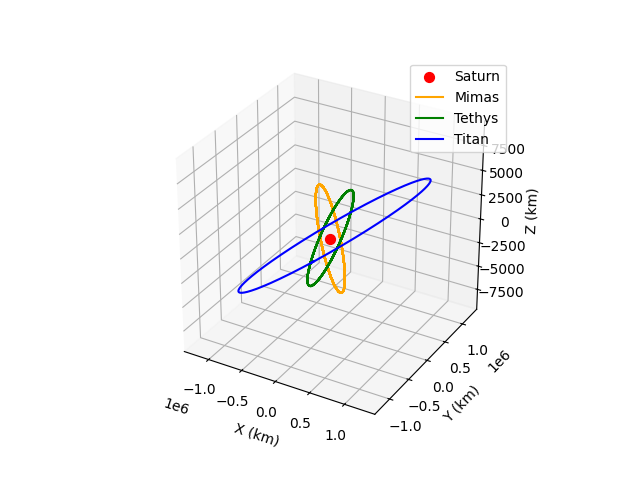

In [9]:
%matplotlib widget

def plot_3d(sim, t):
    """3D plot of the simulation at time step `t`."""
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect((1, 1, 1))

    c = [body.color for body in sim.bodies]
    b = [body.name for body in sim.bodies]
    s = [body.radius for body in sim.bodies]
    s = s * 100 / np.linalg.norm(s)

    x, y, z = np.rollaxis(sim.pos, 2)
    
    # Plot central body
    ax.scatter(x[t, 0], y[t, 0], z[t, 0], c=c[0], s=s[0]*50, label=b[0])

    # Plot paths and bodies
    for i in range(1, nbodies):
        ax.plot(x[:t, i], y[:t, i], z[:t, i], c=c[i], label=b[i])
        ax.scatter(x[t, i], y[t, i], z[t, i], c=c[i], s=s[i])

    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_zlabel('Z (km)')
    ax.legend()
    plt.show()

# simulating over 16 days
plot_3d(sim, nt-1)

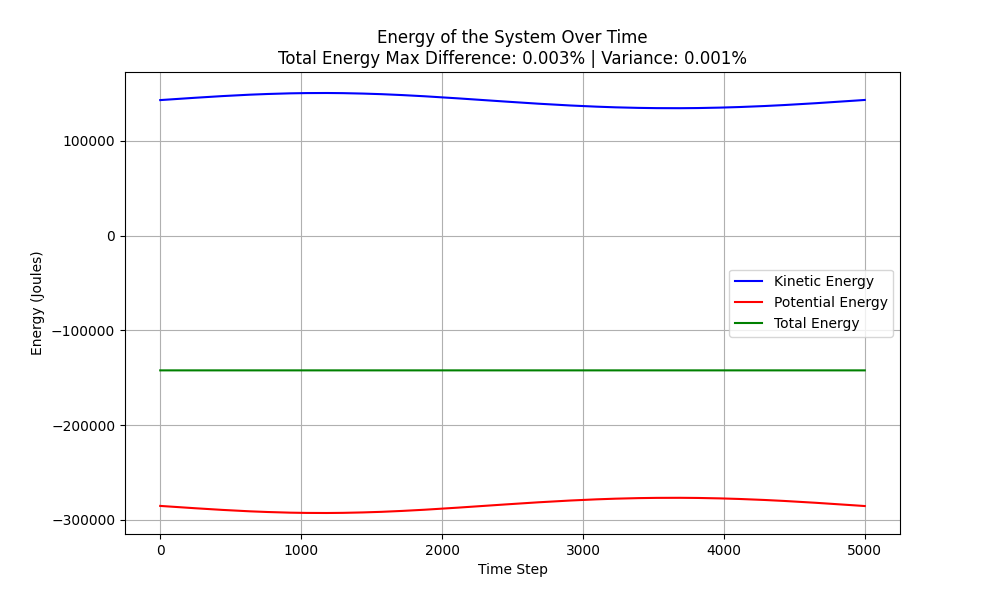

Max Difference in Total Energy: 3.92e+00 J (0.003%)
Mean Total Energy: -1.42e+05 J
Variance of Total Energy: 1.78e+00 J (0.001%)


In [10]:
def plot_total_energy(simulation):
    total_energy = simulation.kinetic_energy + simulation.potential_energy

    # Calculate the mean total energy
    mean_total_energy = np.mean(total_energy)

    # Calculate the maximum difference between any two points and convert it to a percentage
    max_difference = np.max(total_energy) - np.min(total_energy)
    max_difference_percentage = np.absolute((max_difference / mean_total_energy) * 100)

    # Calculate the variance of the total energy
    variance_total_energy = np.var(total_energy)
    variance_percentage = np.absolute((variance_total_energy / mean_total_energy) * 100)

    # Plot the energies
    plt.figure(figsize=(10, 6))
    plt.plot(simulation.kinetic_energy, label='Kinetic Energy', color='b')
    plt.plot(simulation.potential_energy, label='Potential Energy', color='r')
    plt.plot(total_energy, label='Total Energy', color='g')
    plt.xlabel('Time Step')
    plt.ylabel('Energy (Joules)')
    plt.title(f'Energy of the System Over Time\nTotal Energy Max Difference: {max_difference_percentage:.3f}% | Variance: {variance_percentage:.3f}%')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Max Difference in Total Energy: {max_difference:.2e} J ({max_difference_percentage:.3f}%)")
    print(f"Mean Total Energy: {mean_total_energy:.2e} J")
    print(f"Variance of Total Energy: {variance_total_energy:.2e} J ({variance_percentage:.3f}%)")

plot_total_energy(sim)


The Energy graph confirms that the total energy is conserved (only a maximum difference of 0.003 %). which mean that the trajectories are stable and our integration method is validated.

# Orbital Elements and Perturbation

We know want to analyse the Keplerian orbital elements. The following 6 orbital elements were tracked: semi-major axis $a$, eccentricity $e$, inclination $I$, argument of periapsis $\omega$, longitude of ascending node $\Omega$, and mean longitude $\lambda$. 

Firstly we will check the unperturberd system. The orbital elements are plotted below for each of the three moons.

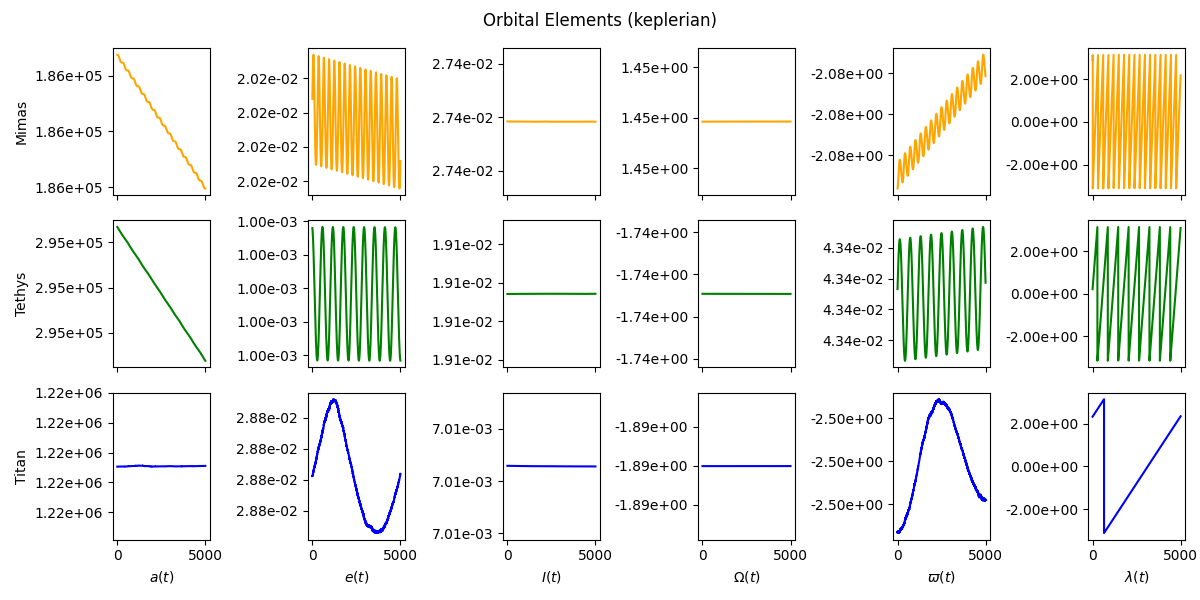

In [11]:
%matplotlib widget

def plot_ell(orb, syst, info):
    fig, axs = plt.subplots(3,6, sharex=True, figsize=(12,6))
    lab = [r'$a(t)$', r'$e(t)$', r'$I(t)$', r'$\Omega(t)$', r'$\varpi(t)$', r'$\lambda(t)$']
    bcl = [body.color for body in syst][1:]
    bnm = [body.name for body in syst][1:]

    for i in range(3):
        for j in range(6):
            axs[i,j].plot(orb[i,j], c=bcl[i])
            axs[-1,j].set(xlabel=lab[j])
            axs[i,0].set(ylabel=bnm[i])
            axs[i,j].yaxis.set_major_formatter(FormatStrFormatter('%.2e'))

    fig.suptitle(f'Orbital Elements ({info})')
    plt.tight_layout()

    #plt.savefig(f'orbital_elements_{info}.png', dpi=300)
    plt.show()

plot_ell(orbital_sim, syst, 'keplerian')

**Note you might have to zoom out to see all the 6 elements**


In the unperturbed system e observe the following: 

- Semi-major axis $a$ : the longest diameter of the two shaping the elliptical orbit of the object. We can see that the semi-major axis linearly decrease, although slighlty, for Mimas and Tethys while it remias constant for Titan

- Eccentricity $e$ : the eccentricity quantifies how elliptical or circular an orbit is. it oscilalte for the three moons, however the average value, is of the order of $10^{-3}$, is close enough to zero to consider the orbits as circular. we note that for Titan it covers one whole period which is expected since we are simulating 16 days which is the expected period of Titan.

- Orbital inclination $I$: this is the tilt of the orbital plane relative to a reference plane, which provides information about how much the orbit deviates with respect to its initial trajectory. Here in the unperturbed simulation, the inclination is constant over time.

- Longitude of the ascending node $\Omega$: this is the angle between the reference direction (usually the vernal equinox) and the point where the orbit crosses the reference plane moving from south to north. it is also constant over time.

- Longitude of the pericentre $\varpi$: this variable describes the orientation of the ellipse in the orbital plane. It undergos perodic oscillation.

- Mean Longitude $\lambda$: The mean longitude is the average angular distance of an object along its orbit from a reference point. It undergos peridoic oscialltions (for Titan we jus need to increase the duration of the simulation to properly observe this behavior).

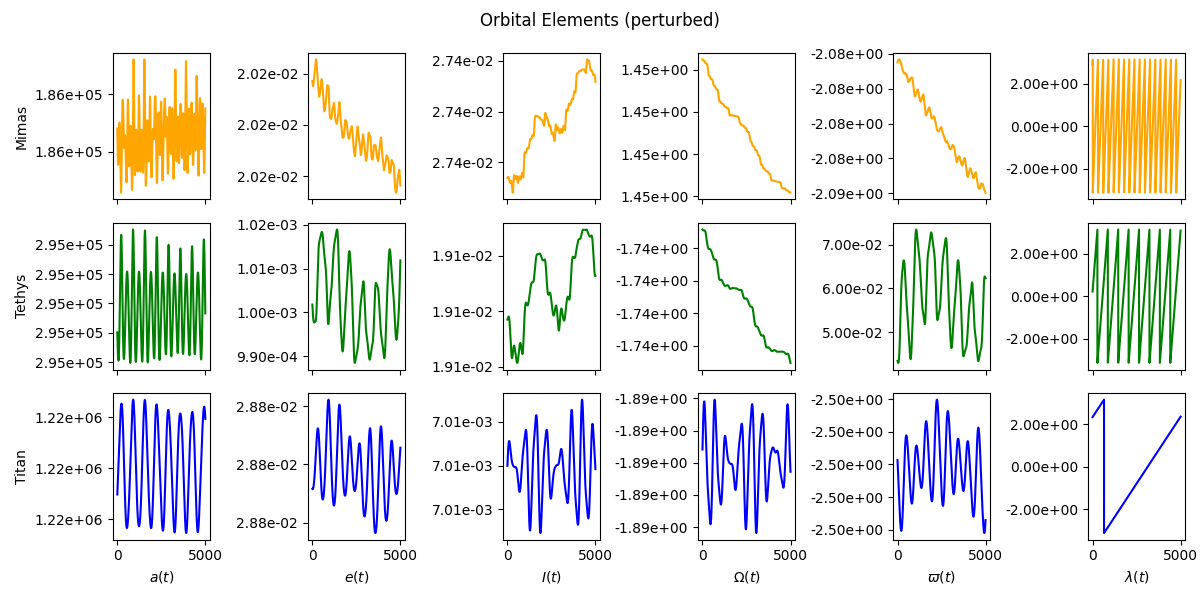

In [12]:
sim_perturb = Simulation(syst, days=16, nt=nt, method=runge_kutta, perturb=perturb)
orbital_sim_perturb = sim_perturb.ell_components()
plot_ell(orbital_sim_perturb, syst, 'perturbed')

In the Perturbed system we observe:

- Semi-major axis $a$ : We can see that the semi-major axis undergoes periodic ocillation when the satelite perturbations are not neglected.

- Eccentricity $e$ : The change in the energy or angular momentum of a satellite over time leads to small perturbations in the orbital shape, which are visible in the variation of the eccentricity. These perturbations have a very small amplitude, and are not strong enough to significantly change their orbit, so it remains circular.

- Orbital inclination $I$: We also observe perturbation, but once again, however, this variation is not significant, with an amplitude of the order of $10^{-2}$.

- Longitude of the ascending node $\Omega$: The same comments as for the inclination apply here.

- Longitude of the pericentre $\varpi$: We now  have a multi-level (2 or 3) oscillations

- Mean Longitude $\lambda$: Same comments  as the unperturbed system


We can notice that Titan's orbital elements are only marginally affected by perturbations, while Mimas and Tethys experience more noticeable changes. this can be attributed to several factors:

- **Mass and Size**: Titan, being significantly larger and more massive than Mimas and Tethys, has more gravitational stability, making it less susceptible to perturbative forces.
- **Orbital Distance**: Titan orbits Saturn at a greater distance, experiencing weaker gravitational interactions with other moons and perturbative forces, leading to more stable orbital elements.

## The flattening of Saturn

Now we consider the flatennig of Saturn, in addition to the perturbation. We once again run the simulation over 32 days (to observe at leat two peaks for Titan) and we will plot $\Omega$ and $\varpi$

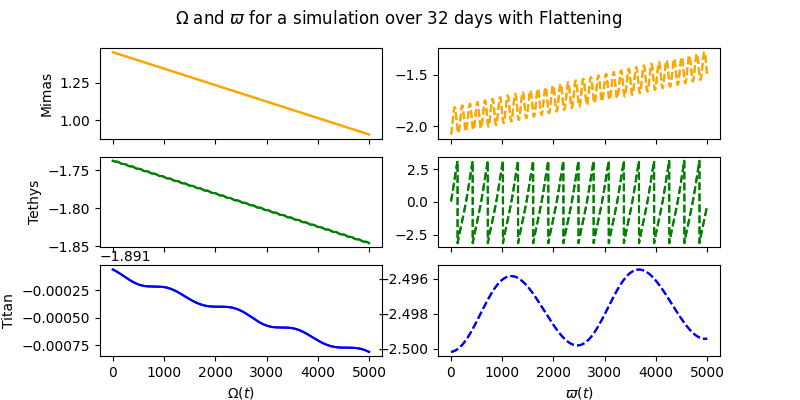

In [13]:
days = 32
sim_perturb_oblat = Simulation(syst, days=days, nt=nt, method=runge_kutta, oblat=oblat)
orbital_sim_perturb_oblat = sim_perturb_oblat.ell_components()


def plt_omega_wd(orb, syst):

    bcl = [body.color for body in syst][1:]
    bnm = [body.name for body in syst][1:]    
    lab = [r"$\Omega(t)$", r"$\varpi(t)$"]

    fig, axs = plt.subplots(3,2, sharex=True, figsize=(8,4))

    for i in range(3):
        for j in range(2):
            #dw = np.diff(w)/np.diff(t)
            omega = orb[i,3]
            wd = orb[i,4]

            axs[i, 0].plot(omega, color=bcl[i])
            axs[i, 1].plot(wd, color=bcl[i], ls='--')
            axs[-1,j].set(xlabel=lab[j])
            axs[i,0].set(ylabel=bnm[i])

    fig.suptitle(rf'$\Omega$ and $\varpi$ for a simulation over {days} days with Flattening ')
    plt.show()

plt_omega_wd(orbital_sim_perturb_oblat, syst)
#plot_ell(orbital_sim_perturb_oblat, syst, 'perturbed and flatenned')

Now we estimate the precession periods using `scipy`

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def estimate_precession_period(time, data, label):
    # Find the peaks in the data
    peaks, _ = find_peaks(data)
    
    if len(peaks) < 2:
        print(f"Not enough peaks found in {label} to estimate precession period.")
        return None
    
    # Calculate the time intervals between consecutive peaks
    peak_times = time[peaks]
    precession_periods = np.diff(peak_times)
    
    # Estimate the precession period as the average time interval between peaks
    avg_precession_period = np.mean(precession_periods)/(24*60*60)
    
    
    print(f"Estimated precession period of {label}: {avg_precession_period:.3f} days")
    return avg_precession_period


# Extract the relevant orbital elements

orb_elements = orbital_sim_perturb_oblat  # Example array
time = np.linspace(0, days*24*60*60, 5000)  # Example time array

# Extract Omega and varpi for Mimas, Tethys, and Titan
omega_mimas = orb_elements[0, 3]  # Omega for Mimas
omega_tethys = orb_elements[1, 3]  # Omega for Tethys
omega_titan = orb_elements[2, 3]  # Omega for Titan

varpi_mimas = orb_elements[0, 4]  # varpi for Mimas
varpi_tethys = orb_elements[1, 4]  # varpi for Tethys
varpi_titan = orb_elements[2, 4]  # varpi for Titan

# Estimate precession periods for Omega and varpi for each satellite
precession_period_omega_mimas = estimate_precession_period(time, omega_mimas, r'Ω for Mimas')
precession_period_omega_tethys = estimate_precession_period(time, omega_tethys, r'Ω for Tethys')
precession_period_omega_titan = estimate_precession_period(time, omega_titan, r'Ω for Titan')

precession_period_varpi_mimas = estimate_precession_period(time, varpi_mimas, r'𝜛 for Mimas')
precession_period_varpi_tethys = estimate_precession_period(time, varpi_tethys, r'𝜛 for Tethys')
precession_period_varpi_titan = estimate_precession_period(time, varpi_titan, r'𝜛 for Titan')


Not enough peaks found in Ω for Mimas to estimate precession period.
Not enough peaks found in Ω for Tethys to estimate precession period.
Not enough peaks found in Ω for Titan to estimate precession period.
Estimated precession period of 𝜛 for Mimas: 0.945 days
Estimated precession period of 𝜛 for Tethys: 1.888 days
Estimated precession period of 𝜛 for Titan: 15.952 days


We estimat the precession periods for Mimas, Tethys, and Titan to be 0.945, 1.888, and 15.952 days, respectively.
This agrees with the know values of the orbital periods for those Satelites obtained from JPL.

## $\dot\Omega$ and $\dot\varpi$

$$
\dot\varpi \approx \frac{3}{2}J_2n\left(\frac{R}{a}\right)^2
$$

$$
\dot\Omega \approx -\frac{3}{2}J_2n\left(\frac{R}{a}\right)^2
$$

with $n=\frac{2\pi}{T}$

**Approach to Obtain Analytical Formulas:**
- Begin with laws of celestial mechanics, considering gravitational interactions between Saturn and satellites.
- Use perturbation theory to account for non-ideal factors like the oblate shape of Saturn and satellite perturbations.
- Derive Perturbation Equations: Obtain differential equations describing the time evolution of $\Omega$ and $\varpi$  in terms of relevant parameters.

To further study $\Omega$ and $\varpi$ we will compare the time evolution of these variables, as computed in our simulation, compared to the theoretical relations for $\dot\Omega$ and $\dot\varpi$ shown wbove. We will do that considering the flattening of Saturn.

Below we plot both the simulation and theoretical vlaues for $\dot\Omega$ and $\dot\varpi$.

<font color='red'>It appears the we should flip the negative sign to get matching graphs</font>, thus we will use:
$
\dot\varpi \approx -\frac{3}{2}J_2n\left(\frac{R}{a}\right)^2
$
and 
$
\dot\Omega \approx \frac{3}{2}J_2n\left(\frac{R}{a}\right)^2
$

Once normalized, the two curves are quite close, although not exactly the same. The general shape is similar, but finer details of the amplitude are more pronounced in the simulation curve ($\dot\Omega$ Tethys). This could be due to the simplifications made in the theoretical model, which are not present in the simulation. The worst match is for the outermost satelite, Titan.

There appear to be a problem which we were not able to resolve with $\dot\varpi$ Tethys.


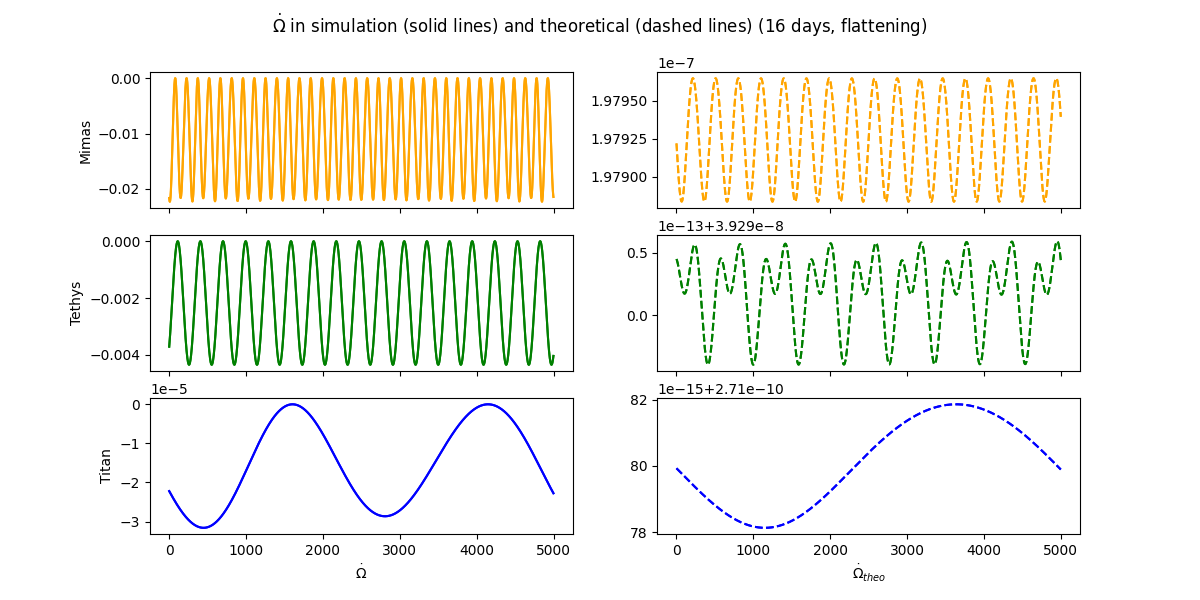

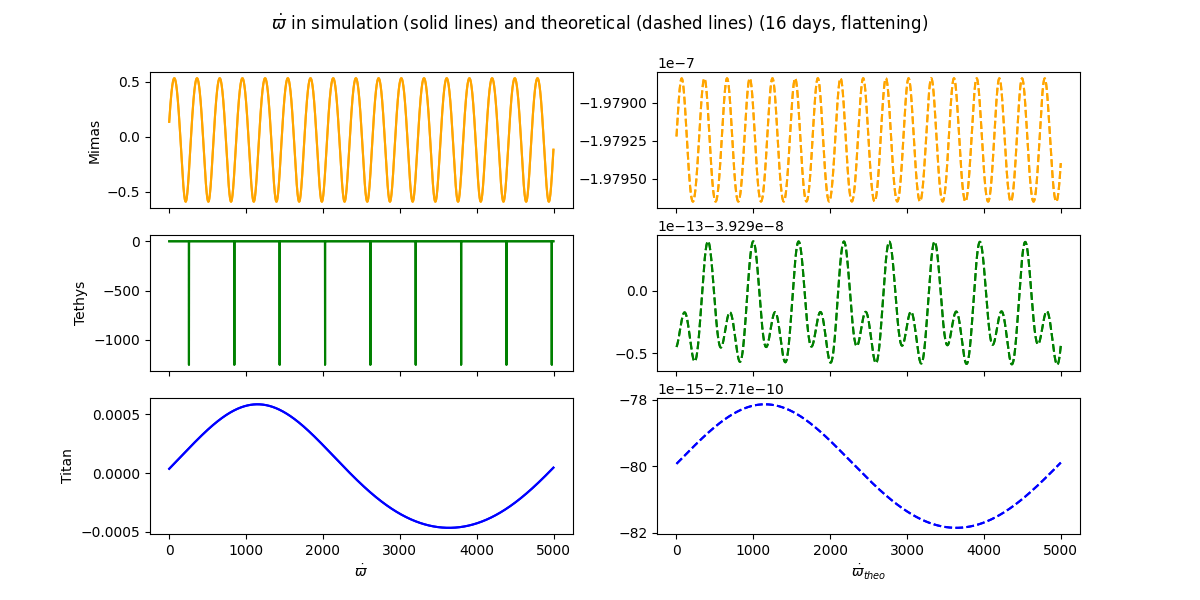

In [15]:
# Data for the three satelites from JPL Horizon
# analytical orbital period of Mimas, Tethys, Titan
T = np.array([0.9424, 1.888, 15.9454])*24*60*60
#a = np.array([[185.540]*(nt-1), [294.670]*(nt-1), [1221.870]*(nt-1)]) #km
#R = np.array([198.8, 536.3, 2575.5]) #km


def plt_time_evolution(orb, syst, variable):

    j2 = 1.629e-2 # Saturn J2
    R = 60268 # Saturn radius
    t = np.linspace(0, nt/200, nt)
    n = 2*np.pi/T
    
    bcl = [body.color for body in syst][1:]
    bnm = [body.name for body in syst][1:]    
    if variable == "omega":
         lab = [r"$\dot\Omega$", r"$\dot\Omega_{theo}$"]
    elif variable=="wd":
        lab = [r"$\dot\varpi$", r"$\dot\varpi_{theo}$"]

    fig, axs = plt.subplots(3,2, sharex=True, figsize=(12,6))

    for i in range(3):
        for j in range(2):
            a=orb[i,0]
            if variable == "omega":
                omega = orb[i,3]
                diff_omega = np.diff(omega)/np.diff(t)
                theo_diff_omega = 3/2*j2*n[i]*R**2/a**2

            elif variable=="wd":
                omega = orb[i,4]
                diff_omega = np.diff(omega)/np.diff(t)
                theo_diff_omega = -3/2*j2*n[i]*R**2/a**2

            axs[i, 0].plot(diff_omega, color=bcl[i])
            axs[i, 1].plot(theo_diff_omega, color=bcl[i], ls='--')
            
            #axs[i, 0].plot(diff_wd, color=bcl[i])
            #axs[i, 1].plot(theo_diff_wd, color=bcl[i], ls='--')
            
            axs[-1,j].set(xlabel=lab[j])
            axs[i,0].set(ylabel=bnm[i])

    #precession_period_omega_mimas = estimate_precession_period(t, diff_omega, rf'{lab[i]} for {bnm[i]}')


    if variable == "omega":
         fig.suptitle(rf'$\dot\Omega$ in simulation (solid lines) and theoretical (dashed lines) ({days} days, flattening)')

    elif variable=="wd":    
        fig.suptitle(rf'$\dot\varpi$ in simulation (solid lines) and theoretical (dashed lines) ({days} days, flattening)')
    plt.show()


days = 16
rk4_oblat = Simulation(syst, days=days, nt=nt, method=runge_kutta, oblat=oblat)
orb_rk4_oblat = rk4_oblat.ell_components()


plt_time_evolution(orb_rk4_oblat, syst, "omega")
plt_time_evolution(orb_rk4_oblat, syst, "wd")


An estimation of the precession period of the $\varpi$ could be
performed with a periodogram, like below; however, we do not
get satisfactory results.

## Orbital resonances

In order to study the resonances we will consider the argument
$$
2\lambda_1 - 4\lambda_3 + \Omega_1 + \Omega_3
$$
where index 1 stands for Mimas, and 3 for Tethys.

We plot this argument below and we can see that it is 2-level periodic oscillation indicating a resonance between Mimas and Tethys.

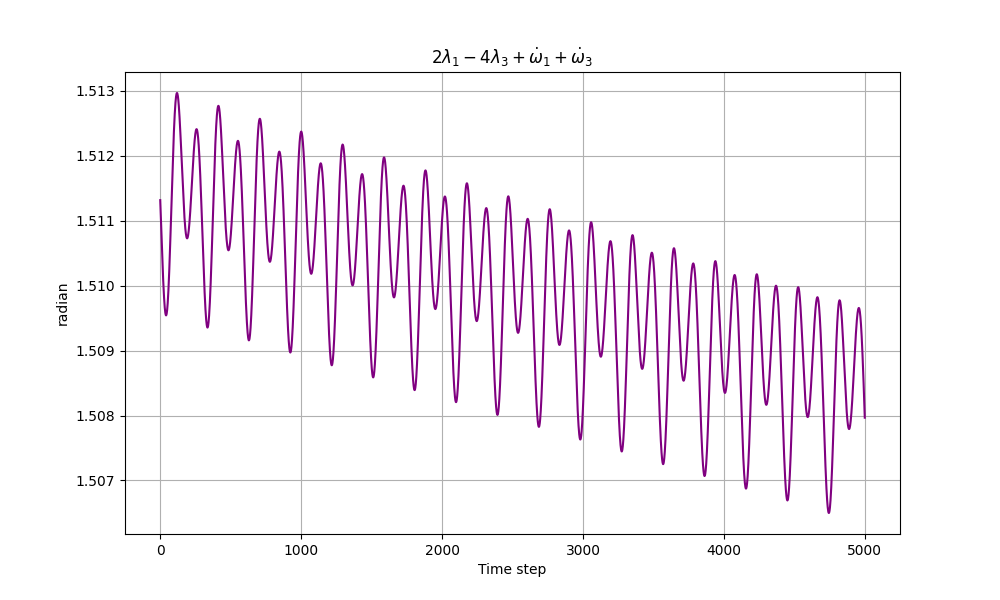

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def plot_argument(orb):
    # Extract mean longitudes and arguments of periapsis
    
    l1 = orb[0, 5]  # λ1 for Mimas
    l3 = orb[1, 5]  # λ3 for Tethys
    
    omega1 = orb[0, 3]  # omega1 for Mimas
    omega3 = orb[1, 3]  # oemga3 for Tethys

    # Calculate the argument
    argument = 2 * l1 - 4 * l3 + omega1 + omega3
    argument = np.mod(argument, 2 * np.pi) - np.pi  # Adjust to range [-π, π]

    # Plot the argument
    plt.figure(figsize=(10, 6))
    plt.plot(argument, label=r'$2\lambda_1 - 4\lambda_3 + \Omega_1 + \Omega_3$', color='purple')
    plt.xlabel('Time step')
    plt.ylabel('radian')
    #plt.legend()
    plt.title('$2\lambda_1 - 4\lambda_3 + \dot{\omega}_1 + \dot{\omega}_3$')
    plt.grid(True)
    plt.show()


# Call the plot_argument function
plot_argument(orb_rk4_oblat)




we can aslo compute the period according to Kepler law for  the three satelites. we deduce a 1:2:17 resonances between the three satelites.

In [17]:
def compute_period(orb):

    def kepler_third_law(a, GM):
        return 2 * np.pi * np.sqrt(a**3 / (GM))
    
    a_mimas = orb[0, 0]  # a1 for Mimas
    a_tethys = orb[1, 0]  # a2 for Tethys
    a_titan = orb[2, 0]  # a2 for Titan

    GM_saturn = Saturn.gm
    GM_mimas = Mimas.gm
    GM_tethys = Tethys.gm
    GM_titan = Titan.gm


    # Calculate theoretical periods using Kepler's Third Law
    T_mimas_theoretical = kepler_third_law(a_mimas,  GM_saturn+GM_mimas)
    T_tethys_theoretical = kepler_third_law(a_tethys, GM_saturn+GM_tethys)
    T_titan_theoretical = kepler_third_law(a_titan, GM_saturn+GM_titan)


    print(f"Theoretical period of Mimas: {np.average(T_mimas_theoretical) / (24 * 60 * 60):.3f} days")
    print(f"Theoretical period of Tethys: {np.average(T_tethys_theoretical) / (24 * 60 * 60):.3f} days")
    print(f"Theoretical period of Titan: {np.average(T_titan_theoretical) / (24 * 60 * 60):.3f} days")
    print(f"\nThere is a {1}:{np.average(T_tethys_theoretical)/np.average(T_mimas_theoretical):.0f}:{np.average(T_titan_theoretical)/np.average(T_mimas_theoretical):.0f} resonance between Mimas, Tethys, and Titan")

compute_period(orb_rk4_oblat)

Theoretical period of Mimas: 0.947 days
Theoretical period of Tethys: 1.892 days
Theoretical period of Titan: 15.948 days

There is a 1:2:17 resonance between Mimas, Tethys, and Titan


# Conclusion
This project explored the orbital dynamics of Saturn's satellites, Mimas, Tethys, and Titan. The simulations successfully demonstrated their Keplerian motion, the effects of mutual perturbations, and the impact of Saturn's oblateness on orbital precession. Additionally, we investigated the orbital resonances, and found out that there is a 1:2:17 resonance between Mimas, Tethys, and Titan.  